In [1]:
## importing packages ##
import numpy as np
import pandas as pd

import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
%matplotlib inline
import re
from imp import reload

from bs4 import BeautifulSoup as bs
import requests


import string
import nltk
from nltk.stem import WordNetLemmatizer 
from nltk.corpus import stopwords,wordnet 
from wordcloud import WordCloud
# nltk.download('averaged_perceptron_tagger')
# nltk.download('vader_lexicon')
# nltk.download('wordnet')

from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import LatentDirichletAllocation
import pyLDAvis
import pyLDAvis.sklearn
pyLDAvis.enable_notebook()


import warnings
warnings.filterwarnings("ignore")

C:\Users\kavia\AppData\Local\Temp\ipykernel_39784\2977375178.py:10: DeprecationWarning: the imp module is deprecated in favour of importlib; see the module's documentation for alternative uses
  from imp import reload


In [2]:
mbenz = pd.read_csv('../preprocesseddata/mbenz.csv')

In [3]:
# from https://medium.com/swlh/sentiment-analysis-topic-modeling-for-hotel-reviews-6b83653f5b08

#Create a function to build the optimal LDA model
def optimal_lda_model(df_tweets, tweets_colname, stop_words):
    '''
    INPUTS:
        df_review - dataframe that contains the reviews
        review_colname: name of column that contains reviews
        
    OUTPUTS:
        lda_tfidf - Latent Dirichlet Allocation (LDA) model
        dtm_tfidf - document-term matrix in the tfidf format
        tfidf_vectorizer - word frequency in the reviews
        A graph comparing LDA Model Performance Scores with different params
    '''
    docs_raw = df_tweets[tweets_colname].tolist()

    #************   Step 1: Convert to document-term matrix   ************#

    # Transform text to vector form using the vectorizer object
    tf_vectorizer = CountVectorizer(stop_words = ['english'] + stop_words,
                                    lowercase = True,
                                    ngram_range=(1, 2),
                                    # token_pattern = r'\b[a-zA-Z]{3,}\b', # num chars > 3 to avoid some meaningless words
                                    min_df = 10)                         # discard words that appear in < 10 tweets    

    #apply transformation
    tfidf_vectorizer = TfidfVectorizer(**tf_vectorizer.get_params())

    #convert to document-term matrix
    dtm_tfidf = tfidf_vectorizer.fit_transform(docs_raw)  

    print(f"The shape of the tfidf is {dtm_tfidf.shape}, meaning that there are {dtm_tfidf.shape[0]} {tweets_colname} and {dtm_tfidf.shape[1]} tokens made through the filtering process.")



    #*******   Step 2: GridSearch & parameter tuning to find the optimal LDA model   *******#

    # Define Search Param
    search_params = {'n_components': [5, 10], 
                     'learning_decay': [.5, .7]}

    # Init the Model
    lda = LatentDirichletAllocation()

    # Init Grid Search Class
    model = GridSearchCV(lda, param_grid=search_params)

    # Do the Grid Search
    model.fit(dtm_tfidf)


    #*****  Step 3: Output the optimal lda model and its parameters  *****#

    # Best Model
    best_lda_model = model.best_estimator_

    # Model Parameters
    print("Best Model's Params: ", model.best_params_)

    # Log Likelihood Score: Higher the better
    print("Model Log Likelihood Score: ", model.best_score_)

    # Perplexity: Lower the better. Perplexity = exp(-1. * log-likelihood per word)
    print("Model Perplexity: ", best_lda_model.perplexity(dtm_tfidf))


    #***********   Step 4: Compare LDA Model Performance Scores   ***********#

    #Get Log Likelyhoods from Grid Search Output
    gscore=model.fit(dtm_tfidf).cv_results_
    n_topics = [5, 10]

    log_likelyhoods_5 = [gscore['mean_test_score'][gscore['params'].index(v)] for v in gscore['params'] if v['learning_decay']==0.5]
    log_likelyhoods_7 = [gscore['mean_test_score'][gscore['params'].index(v)] for v in gscore['params'] if v['learning_decay']==0.7]

    # Show graph
    plt.figure(figsize=(12, 8))
    plt.plot(n_topics, log_likelyhoods_5, label='0.5')
    plt.plot(n_topics, log_likelyhoods_7, label='0.7')
    plt.title("Choosing Optimal LDA Model")
    plt.xlabel("Num Topics")
    plt.ylabel("Log Likelyhood Scores")
    plt.legend(title='Learning decay', loc='best')
    plt.show()

    return best_lda_model, dtm_tfidf, tfidf_vectorizer


In [9]:
# Add my own words to the stop_words
mbenz_stop_words = ['@user', '@http', 'user', 'http','https', 'ev', 'electric', 'car', 'cars', 'model', 'models',
                   'the', 'to', 'is', 'in', 'benz', 'its', 'all', 'it', 'with', 'mercedes', 'eqb', 'eqs', 'on', 'at',
                   'of', 'and', 'you', 'for', 'this', 'that', 'will', 'be'] 

The shape of the tfidf is (7728, 2468), meaning that there are 7728 Text and 2468 tokens made through the filtering process.
Best Model's Params:  {'learning_decay': 0.5, 'n_components': 5}
Model Log Likelihood Score:  -54054.56972441469
Model Perplexity:  2376.0806352987097


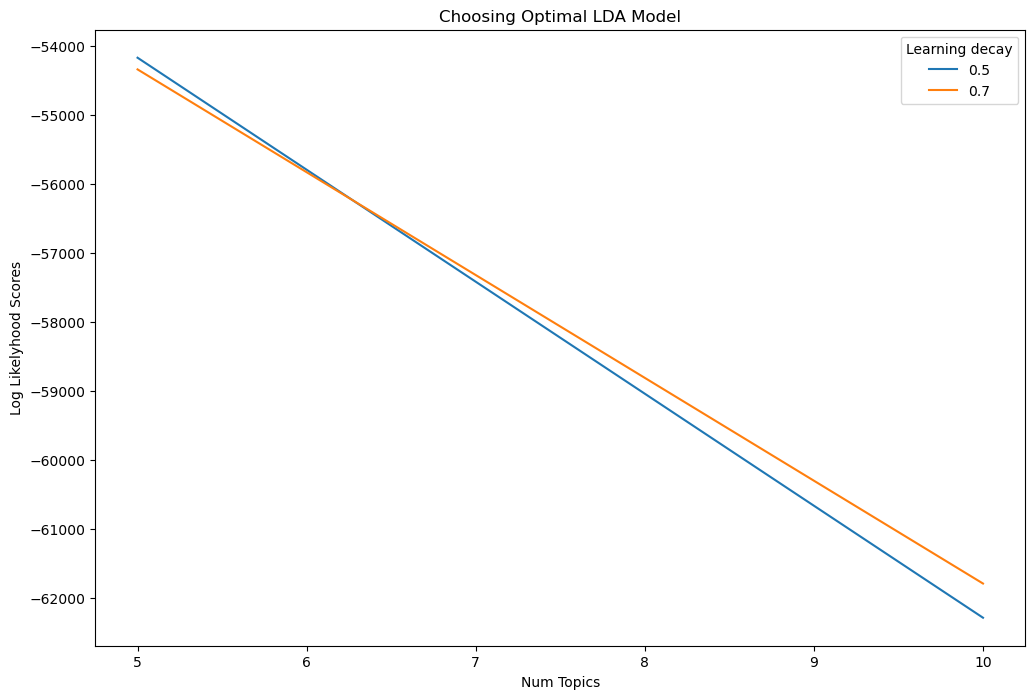

In [10]:
best_lda_model, dtm_tfidf, tfidf_vectorizer = optimal_lda_model(mbenz, 'Text', mbenz_stop_words)

In [11]:
#Create a function to inspect the topics we created 
def display_topics(model, feature_names, n_top_words):
    '''
    INPUTS:
        model - the model we created
        feature_names - tells us what word each column in the matric represents
        n_top_words - number of top words to display
    OUTPUTS:
        a dataframe that contains the topics we created and the weights of each token
    '''
    topic_dict = {}
    for topic_idx, topic in enumerate(model.components_):
        topic_dict[f"Topic {topic_idx+1} words"] = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        topic_dict[f"Topic {topic_idx+1} weights"] = [f'{topic[i]:.1f}' for i in topic.argsort()[:-n_top_words - 1:-1]]

    return pd.DataFrame(topic_dict)


display_topics(best_lda_model, tfidf_vectorizer.get_feature_names(), n_top_words = 10)

,Topic 1 words,Topic 1 weights,Topic 2 words,Topic 2 weights,Topic 3 words,Topic 3 weights,Topic 4 words,Topic 4 weights,Topic 5 words,Topic 5 weights
0,version,52.3,luxury,86.6,amg,90.5,suv,116.9,new,58.0
1,truck,49.0,2022,81.8,range,73.3,new,71.4,eqsisthefuture,56.7
2,22,47.6,new,76.9,luxury,72.5,glb,45.2,limitlesseqs,56.3
3,fire,46.4,suv,64.8,class,62.2,new suv,44.6,eqsisthefuture limitlesseqs,51.8
4,link,46.1,future,64.6,sedan,57.9,but,40.7,luxury,37.1
5,farming simulator,45.6,eq,56.3,india,51.9,are,40.5,sedan,29.5
6,link tags,45.6,mercedesbenz,55.2,via,49.4,vehicle,39.9,announces,28.4
7,simulator,45.6,co,54.5,4matic,45.4,like,39.2,thisisforyouworld,28.3
8,farming,45.6,from,47.5,new,44.3,built,39.1,thisisforyouworld eqsisthefuture,27.6
9,22 link,45.6,fully,44.8,has,44.0,first,37.8,us,27.5


In [12]:
# Topic Modelling Visualization for the Negative Reviews
pyLDAvis.sklearn.prepare(best_lda_model, dtm_tfidf, tfidf_vectorizer)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3     -0.083717 -0.141561       1        1  25.817829
2     -0.040997 -0.127950       2        1  22.246660
1     -0.081932  0.057142       3        1  22.110341
4     -0.082202  0.198780       4        1  16.190802
0      0.288848  0.013589       5        1  13.634368, topic_info=                Term       Freq       Total Category  logprob  loglift
756   eqsisthefuture  91.000000   91.000000  Default  30.0000  30.0000
2257           truck  49.000000   49.000000  Default  29.0000  29.0000
2356         version  64.000000   64.000000  Default  28.0000  28.0000
69                22  47.000000   47.000000  Default  27.0000  27.0000
1251    limitlesseqs  79.000000   79.000000  Default  26.0000  26.0000
...              ...        ...         ...      ...      ...      ...
120               56  20.985527   39.970545   Topic5  -5.1452   1.3483
1741      production  23.275225   55.021815   Topic5  -5.0416   1.1322
1089     hyperscreen  20.910806   58.456466   Topic5  -5.1487   0.9646
900         flagship  21.820596   90.635729   Topic5  -5.1062   0.5686
2092             suv  24.073921  244.949461   Topic5  -5.0079  -0.3273

[315 rows x 6 columns], token_table=      Topic      Freq   Term
term                        
36        1  0.140666   2022
36        2  0.191817   2022
36        3  0.460362   2022
36        4  0.166242   2022
36        5  0.044757   2022
...     ...       ...    ...
2400      3  0.117661     we
2400      4  0.078440     we
2405      1  0.943902  we ve
2405      2  0.067422  we ve
2430      1  0.941042    why

[502 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 3, 2, 5, 1])

topics:
- new suv
- luxury
- advertisement tweets

In [13]:
p = pyLDAvis.sklearn.prepare(best_lda_model, dtm_tfidf, tfidf_vectorizer)
pyLDAvis.save_html(p, '../links/mbenz_topic_modeling.html')